# Physical Activity

In [93]:
%pip install -q -r ../../requirements.txt

# If this block is stuck: 
# Press: Ctrl + Shift + P
# Run: Developer: Reload Window


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
# import seaborn as sns
import matplotlib.pyplot as plt
# from scipy.stats import entropy
import pandas as pd
import os
import numpy as np


In [95]:
DAILY_MERGE_KEYS = ["id", "day_in_study", "is_weekend", "study_interval"]


In [96]:
data_dir = '../../mcphases/'


### Prepare the individual dataframes

is_weekend kept on active_minutes only to facilitate merging;

active_minutes: sedentary, lightly, moderately, very

calories: calories (daily sum based on day_in_study)

demographic_vo2_max: filtered_demographic_vo2_max, filtered_demographic_vo2_max_error

(REMOVE) exercise: start_day_in_study as day_in_study, 
    activitylevel (looks like: "[{'minutes': 0, 'name': 'sedentary'}, {'minutes': 3, 'name': 'lightly'}, {'minutes': 11, 'name': 'fairly'}, {'minutes': 2, 'name': 'very'}]"), 
    heartratezones (looks like: "[{'name': 'Out of Range', 'min': 30, 'max': 121, 'minutes': 16, 'caloriesOut': 69.75168}, {'name': 'Fat Burn', 'min': 121, 'max': 143, 'minutes': 0, 'caloriesOut': 0.0}, {'name': 'Cardio', 'min': 143, 'max': 171, 'minutes': 0, 'caloriesOut': 0.0}, {'name': 'Peak', 'min': 171, 'max': 220, 'minutes': 0, 'caloriesOut': 0.0}]")

time_in_heart_rate_zones: in_default_zone_3, in_default_zone_2, in_default_zone_1, below_default_zone_1

(REMOVE) height_and_weight: height_2022, height_2024, weight_2022, weight_2024 --> calculate BMI

subject_info: birth_year --> age, ethnicity, sexually_active, self_report_menstrual_health_literacy --> convert to numerical feature, age_of_first_menarche

hormones_and_selfreport: phase, lh, estrogen, pdg, exerciselevel, fatigue

glucose: timestamp (not a feature), glucose_value

heart_rate_variability_details: timestamp (not a feature), rmssd, coverage(not a feature)

sleep_score: overal_score, timestamp (not a feature)


#### Active minutes

In [97]:
active_minutes = pd.read_csv(os.path.join(data_dir, 'active_minutes.csv'))


In [98]:
active_minutes.head()


,id,study_interval,is_weekend,day_in_study,sedentary,lightly,moderately,very
0,1,2022,True,1,753.0,64,0,0
1,1,2022,False,2,855.0,74,0,0
2,1,2022,False,3,751.0,134,18,7
3,1,2022,False,4,905.0,86,0,0
4,1,2022,False,5,1430.0,10,0,0


In [99]:
# Look at the proportion of exact duplicate rows in active_minutes
n_dup_rows = active_minutes.duplicated().sum()
n_total_rows = len(active_minutes)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")


Exact duplicate rows: 71/5552
Proportion: 1.28%


In [100]:
# Remove exact duplicate rows, keeping the first occurrence
active_minutes = active_minutes.drop_duplicates()


In [101]:
# Is there multiple entries for the same participant on the same day? Let's check.
active_minutes.groupby(
    DAILY_MERGE_KEYS
).size().sort_values(ascending=False).head(10)


id  day_in_study  is_weekend  study_interval
50  951           False       2024              1
1   1             True        2022              1
    2             False       2022              1
    3             False       2022              1
    4             False       2022              1
    5             False       2022              1
    6             False       2022              1
    7             True        2022              1
    8             True        2022              1
50  935           False       2024              1
dtype: int64

No, each participant-day appears only once.

In [102]:
# Verify that there are no more duplicates
active_minutes.duplicated(DAILY_MERGE_KEYS).sum()


np.int64(0)

In [104]:
# Rename sedentary, lightly, moderately, and very to x_activity
active_minutes = active_minutes.rename(columns={
    "sedentary": "sedentary_activity",
    "lightly": "lightly_activity",
    "moderately": "moderately_activity",
    "very": "very_activity",
})


In [105]:
active_minutes

,id,study_interval,is_weekend,day_in_study,sedentary_activity,lightly_activity,moderately_activity,very_activity
0,1,2022,True,1,753.0,64,0,0
1,1,2022,False,2,855.0,74,0,0
2,1,2022,False,3,751.0,134,18,7
3,1,2022,False,4,905.0,86,0,0
4,1,2022,False,5,1430.0,10,0,0
...,...,...,...,...,...,...,...,...
5547,50,2024,False,947,NaN,214,21,60
5548,50,2024,False,948,NaN,198,0,0
5549,50,2024,False,949,NaN,68,15,39
5550,50,2024,False,950,NaN,8,0,0


#### Calories

In [106]:
calories = pd.read_csv(os.path.join(data_dir, 'calories.csv'))


In [107]:
daily_calories = (
    calories
    .groupby(DAILY_MERGE_KEYS, as_index=False)
    .agg(calories_sum=("calories", "sum"))
)

daily_calories.head()


,id,day_in_study,is_weekend,study_interval,calories_sum
0,1,1,True,2022,1542.0
1,1,2,False,2022,1591.0
2,1,3,False,2022,1755.0
3,1,4,False,2022,1552.0
4,1,5,False,2022,1456.0


In [108]:
# Look at the proportion of exact duplicate rows in daily_calories
n_dup_rows = daily_calories.duplicated().sum()
n_total_rows = len(daily_calories)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")


Exact duplicate rows: 0/5655
Proportion: 0.00%


#### Demographic VO2 max

In [109]:
demographic_vo2_max = pd.read_csv(os.path.join(data_dir, 'demographic_vo2_max.csv'))


In [110]:
demographic_vo2_max["filtered_demographic_vo2_max"].describe()


count    11482.000000
mean      7822.533262
std      10199.147630
min         24.548290
25%         34.920210
50%         43.321700
75%      21474.836470
max      21474.836470
Name: filtered_demographic_vo2_max, dtype: float64

The normal distribution of VO2 is below 10-90. Something certainly went wrong.

In [111]:
print(demographic_vo2_max[
    demographic_vo2_max["filtered_demographic_vo2_max"] > 90
].shape)

print(demographic_vo2_max.shape)


(4778, 8)
(11482, 8)


About 40% of the data is invalid -- do not make sense.

In [112]:
(
    demographic_vo2_max.loc[
        demographic_vo2_max["filtered_demographic_vo2_max"] > 90,
        "filtered_demographic_vo2_max"
    ]
    .value_counts()
    .head(20)
)


filtered_demographic_vo2_max
21474.83647    4071
1719.30929       30
15055.24327      16
12836.16711      16
11029.01284      16
17846.72171      16
8271.08867       16
7201.50779       16
6286.00887       16
5497.53187       16
4815.24668       16
4222.81563       16
3706.93104       16
9530.59761       16
3256.65093       16
2862.93615       16
2216.34569       16
2518.26935       16
1336.48290       16
1515.41435       16
Name: count, dtype: int64

In [113]:
demographic_vo2_max.groupby("id")[
    "filtered_demographic_vo2_max"
].max().sort_values(ascending=False).head(20)


id
9     21474.83647
10    21474.83647
22    21474.83647
26    21474.83647
30    21474.83647
20    21474.83647
18    21474.83647
14    21474.83647
13    21474.83647
12    21474.83647
50    21474.83647
43    21474.83647
48    21474.83647
47    21474.83647
42    21474.83647
41    21474.83647
38    21474.83647
33    21474.83647
32    21474.83647
27    21474.83647
Name: filtered_demographic_vo2_max, dtype: float64

Invalid data is not from a single mal-functioning device, but rather across participants.

In [114]:
demographic_vo2_max.groupby("study_interval")[
    "filtered_demographic_vo2_max"
].describe()


,count,mean,std,min,25%,50%,75%,max
study_interval,,,,,,,,
2022,3531.0,38.719237,4.977277,26.89121,35.233445,39.02958,41.789405,52.51878
2024,7951.0,11279.286792,10552.894565,24.54829,34.197280,21474.83647,21474.836470,21474.83647


In [115]:
demographic_vo2_max.groupby("study_interval").apply(
    lambda x: (
        (x["filtered_demographic_vo2_max"] > 90) |
        (x["filtered_demographic_vo2_max"] < 10)
    ).mean() * 100
)


C:\Users\caowe\AppData\Local\Temp\ipykernel_36532\1504777471.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  demographic_vo2_max.groupby("study_interval").apply(


study_interval
2022     0.00000
2024    60.09307
dtype: float64

It seems that all corrupted data are from the second study interval.

In [116]:
# Replace outliers with NaN in demographic_vo2_max
mask = (
    (demographic_vo2_max["filtered_demographic_vo2_max"] < 10) |
    (demographic_vo2_max["filtered_demographic_vo2_max"] > 90)
)

demographic_vo2_max.loc[mask, "filtered_demographic_vo2_max"] = np.nan

demographic_vo2_max["filtered_demographic_vo2_max"].describe()


count    6704.000000
mean       36.190549
std         8.959272
min        24.548290
25%        26.587650
50%        36.206935
75%        41.232480
max        87.530170
Name: filtered_demographic_vo2_max, dtype: float64

In [117]:
demographic_vo2_max = demographic_vo2_max.drop(columns=[
    "demographic_vo2_max", "demographic_vo2_max_error", "filtered_demographic_vo2_max_error"])
    
demographic_vo2_max.head()


,id,study_interval,is_weekend,day_in_study,filtered_demographic_vo2_max
0,1,2022,True,1,33.79370
1,1,2022,False,2,32.55987
2,1,2022,False,3,31.50628
3,1,2022,False,4,31.06774
4,1,2022,False,5,30.88130


In [118]:
demographic_vo2_daily = (
    demographic_vo2_max
    .groupby(DAILY_MERGE_KEYS, as_index=False)
    .agg({
        "filtered_demographic_vo2_max": "mean"
    })
)
# This method ignores nan values when calculating the mean, 
# so it will give us the average of the remaining values after we replaced outliers with NaN.


In [119]:
# Take a look at the missing values in demographic_vo2_daily
missing = demographic_vo2_daily.isna().sum()
missing_percent = demographic_vo2_daily.isna().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_percent.round(2)
})

print(missing_summary)


                              Missing Count  Missing (%)
id                                        0         0.00
day_in_study                              0         0.00
is_weekend                                0         0.00
study_interval                            0         0.00
filtered_demographic_vo2_max            118         2.15


#### (REMOVE) Exercise

In [25]:
exercise = pd.read_csv(os.path.join(data_dir, 'exercise.csv'))


In [26]:
print("Total rows:", len(exercise))
print("Duplicates:", exercise.duplicated().sum())


Total rows: 7282
Duplicates: 3641


In [27]:
exercise.groupby(list(exercise.columns)).size().value_counts()


1    2382
5     363
6     242
2     111
7      45
8      30
4       1
Name: count, dtype: int64

In [28]:
exercise_unique = exercise.drop_duplicates()
print("Exact duplicates for new dataframe:", exercise_unique.duplicated().sum())


Exact duplicates for new dataframe: 0


In [29]:
exercise_unique = exercise_unique.drop(columns=["study_interval", "last_modified_day_in_study", "last_modified_timestamp", "activitytypeid",
                                                "original_start_day_in_study", "original_start_timestamp", "originalduration", "duration",
                                                "manualvaluesspecified", "logtype", "hasgps", "shouldfetchdetails", "hasactivezoneminutes"])
exercise_unique = exercise_unique.rename(columns={"start_day_in_study": "day_in_study"})
exercise_unique.head(5)


,id,is_weekend,day_in_study,start_timestamp,activityname,activitylevel,averageheartrate,calories,activeduration,steps,heartratezones,activezoneminutes,elevationgain
0,1,False,39,21:23:14,Walk,"[{'minutes': 0, 'name': 'sedentary'}, {'minute...",106.0,96,1127000,1848.0,"[{'name': 'Out of Range', 'min': 30, 'max': 12...","{'totalMinutes': 1, 'minutesInHeartRateZones':...",18.288
1,1,False,39,21:23:14,Walk,"[{'minutes': 0, 'name': 'sedentary'}, {'minute...",106.0,96,1127000,1848.0,"[{'name': 'Out of Range', 'min': 30, 'max': 12...","{'totalMinutes': 1, 'minutesInHeartRateZones':...",18.288
7,1,False,44,19:56:44,Outdoor Bike,"[{'minutes': 24, 'name': 'sedentary'}, {'minut...",91.0,30,1639000,NaN,"[{'name': 'Out of Range', 'min': 30, 'max': 12...","{'totalMinutes': 0, 'minutesInHeartRateZones':...",0.000
10,1,False,44,18:33:58,Walk,"[{'minutes': 0, 'name': 'sedentary'}, {'minute...",100.0,268,3430000,5356.0,"[{'name': 'Out of Range', 'min': 30, 'max': 12...","{'totalMinutes': 0, 'minutesInHeartRateZones':...",3.454
14,1,False,44,18:33:58,Walk,"[{'minutes': 0, 'name': 'sedentary'}, {'minute...",100.0,268,3430000,5356.0,"[{'name': 'Out of Range', 'min': 30, 'max': 12...","{'totalMinutes': 0, 'minutesInHeartRateZones':...",3.454


#### Time in heart rate zones

In [120]:
time_in_heart_rate_zones = pd.read_csv(os.path.join(data_dir, 'time_in_heart_rate_zones.csv'))


In [121]:
time_in_heart_rate_zones.head()


,id,study_interval,is_weekend,day_in_study,in_default_zone_3,in_default_zone_2,in_default_zone_1,below_default_zone_1
0,1,2022,True,1,0.0,0.0,126.0,1036.0
1,1,2022,False,2,5.0,82.0,416.0,512.0
2,1,2022,False,3,5.0,119.0,599.0,368.0
3,1,2022,False,4,0.0,0.0,212.0,613.0
4,1,2022,False,5,8.0,123.0,250.0,308.0


In [122]:
time_in_heart_rate_zones = time_in_heart_rate_zones.rename(
    columns={"in_default_zone_3": "peak_zone", 
             "in_default_zone_2": "cardio_zone", 
             "in_default_zone_1": "fat_burn_zone", 
             "below_default_zone_1": "below_fat_burn_zone"})
time_in_heart_rate_zones.head()


,id,study_interval,is_weekend,day_in_study,peak_zone,cardio_zone,fat_burn_zone,below_fat_burn_zone
0,1,2022,True,1,0.0,0.0,126.0,1036.0
1,1,2022,False,2,5.0,82.0,416.0,512.0
2,1,2022,False,3,5.0,119.0,599.0,368.0
3,1,2022,False,4,0.0,0.0,212.0,613.0
4,1,2022,False,5,8.0,123.0,250.0,308.0


In [123]:
print("Total rows:", len(time_in_heart_rate_zones))
print("Exact duplicate rows:", time_in_heart_rate_zones.duplicated().sum())
print(f"Proportion: {time_in_heart_rate_zones.duplicated().sum() / len(time_in_heart_rate_zones):.2%}")


Total rows: 5553
Exact duplicate rows: 103
Proportion: 1.85%


In [124]:
# Drop duplicates
time_in_heart_rate_zones = time_in_heart_rate_zones.drop_duplicates()
# Verify that there are no more duplicates
time_in_heart_rate_zones.duplicated(DAILY_MERGE_KEYS).sum()


np.int64(0)

#### (REMOVE) Height and Weight

In [35]:
height_and_weight = pd.read_csv(os.path.join(data_dir, 'height_and_weight.csv'))


In [36]:
cols = ["height_2022", "weight_2022", "height_2024", "weight_2024"]

missing_summary = (
    height_and_weight[cols]
    .isna()
    .sum()
    .to_frame(name="Missing Count")
)

missing_summary["Missing (%)"] = (
    missing_summary["Missing Count"] / len(height_and_weight) * 100
).round(2)

missing_summary


,Missing Count,Missing (%)
height_2022,21,50.00
weight_2022,18,42.86
height_2024,34,80.95
weight_2024,31,73.81


Too much missing data, exclude these features.

In [37]:
height_and_weight["height"] = (
    height_and_weight["height_2022"]
    .fillna(height_and_weight["height_2024"])
)
height_and_weight["weight"] = (
    height_and_weight["weight_2022"]
    .fillna(height_and_weight["weight_2024"])
)
height_and_weight[["height", "weight"]].isna().sum()


height    17
weight    12
dtype: int64

In [38]:
height_and_weight.head()


,id,height_2022,weight_2022,height_2024,weight_2024,height,weight
0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,NaN,NaN,NaN
2,3,167.0,52.0,NaN,NaN,167.0,52.0
3,4,170.0,78.0,NaN,NaN,170.0,78.0
4,6,NaN,NaN,NaN,NaN,NaN,NaN


#### Subject info

In [125]:
subject_info = pd.read_csv(os.path.join(data_dir, 'subject-info.csv'))


In [126]:
print("Total rows:", len(subject_info))
print("Exact duplicate rows:", subject_info.duplicated().sum())
print(f"Proportion: {subject_info.duplicated().sum() / len(subject_info):.2%}")


Total rows: 42
Exact duplicate rows: 0
Proportion: 0.00%


In [127]:
# subject_info: birth_year --> age
subject_info["age"] = 2024 - subject_info["birth_year"]
subject_info = subject_info.drop(columns=["birth_year", "gender", "education", "ethnicity"])
subject_info.head()


,id,sexually_active,self_report_menstrual_health_literacy,age_of_first_menarche,age
0,1,Yes,NaN,14,25
1,2,Yes,High,13,29
2,3,No,High,12,24
3,4,No,Medium,12,24
4,6,Yes,Low,13,27


In [128]:
subject_info["self_report_menstrual_health_literacy"].value_counts()


self_report_menstrual_health_literacy
Medium          23
High            12
Low              4
Expert           1
Non-existent     1
Name: count, dtype: int64

In [129]:
# Convert self-report menstrual health literacy to numeric values
literacy_mapping = {
    "Non-existent": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Expert": 4
}

subject_info["menstrual_health_literacy_num"] = (
    subject_info["self_report_menstrual_health_literacy"]
    .map(literacy_mapping)
)
subject_info = subject_info.drop(columns=["self_report_menstrual_health_literacy"])
subject_info.head(100)


,id,sexually_active,age_of_first_menarche,age,menstrual_health_literacy_num
0,1,Yes,14,25,NaN
1,2,Yes,13,29,3.0
2,3,No,12,24,3.0
3,4,No,12,24,2.0
4,6,Yes,13,27,1.0
5,7,Yes,10,23,2.0
6,8,Yes,10,24,3.0
7,9,No,13,20,2.0
8,10,No,11,22,3.0
9,11,No,12,21,2.0


In [44]:
# subject_info["ethnicity"].value_counts()


In [45]:
# ethnicity_dummies = pd.get_dummies(
#     subject_info["ethnicity"],
#     prefix="ethnicity",
#     dtype=int
# )

# subject_info = pd.concat(
#     [subject_info, ethnicity_dummies],
#     axis=1
# )
# subject_info.head(100)


In [130]:
# Convert self-report sexually_active to numeric values
sexually_active_mapping = {
    "No": 0,
    "Yes": 1
}
# "Prefer not to say" is mapped to NaN, which will be handled later

subject_info["sexually_active_num"] = (
    subject_info["sexually_active"]
    .map(sexually_active_mapping)
)
subject_info = subject_info.drop(columns=["sexually_active"])
subject_info.head(100)


,id,age_of_first_menarche,age,menstrual_health_literacy_num,sexually_active_num
0,1,14,25,NaN,1.0
1,2,13,29,3.0,1.0
2,3,12,24,3.0,0.0
3,4,12,24,2.0,0.0
4,6,13,27,1.0,1.0
5,7,10,23,2.0,1.0
6,8,10,24,3.0,1.0
7,9,13,20,2.0,0.0
8,10,11,22,3.0,0.0
9,11,12,21,2.0,0.0


#### Hormones and self-report

In [131]:
hormones_and_selfreport = pd.read_csv(os.path.join(data_dir, 'hormones_and_selfreport.csv'))


In [132]:
# Convert self-report symptoms to numeric values
likert_map = {
    'Not at all': 0,
    'Very Low/Little': 1,
    'Very Low': 1,
    'Low': 2,
    'Moderate': 3,
    'High': 4,
    'Very High': 5
}

symptoms = [
    'appetite',
    'exerciselevel',
    'headaches',
    'cramps',
    'sorebreasts',
    'fatigue',
    'sleepissue',
    'moodswing',
    'stress',
    'foodcravings',
    'indigestion',
    'bloating'
]

for col in symptoms:
    hormones_and_selfreport[col + '_num'] = (
        hormones_and_selfreport[col]
        .map(likert_map)
    )


In [133]:
# Should return empty if all labels mapped
for col in symptoms + ['exerciselevel']:
    unmapped = hormones_and_selfreport.loc[
        hormones_and_selfreport[col].notna() &
        hormones_and_selfreport[col + '_num'].isna(),
        col
    ].unique()
    print(f"Unmapped values for {col}: {unmapped}")


Unmapped values for appetite: []
Unmapped values for exerciselevel: []
Unmapped values for headaches: ['2' '5' '3' '4']
Unmapped values for cramps: []
Unmapped values for sorebreasts: []
Unmapped values for fatigue: []
Unmapped values for sleepissue: []
Unmapped values for moodswing: []
Unmapped values for stress: ['2' '3' '1']
Unmapped values for foodcravings: []
Unmapped values for indigestion: []
Unmapped values for bloating: []
Unmapped values for exerciselevel: []


In [134]:
hormones_and_selfreport.head()


,id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,flow_color,...,headaches_num,cramps_num,sorebreasts_num,fatigue_num,sleepissue_num,moodswing_num,stress_num,foodcravings_num,indigestion_num,bloating_num
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Not at all,Not at all,...,4.0,1.0,1.0,4.0,2.0,1.0,3.0,1.0,1.0,1.0
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Not at all,Not at all,...,5.0,1.0,1.0,4.0,5.0,1.0,3.0,1.0,1.0,1.0
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Not at all,Not at all,...,4.0,1.0,1.0,5.0,5.0,1.0,2.0,1.0,1.0,1.0
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Not at all,Not at all,...,1.0,1.0,1.0,4.0,5.0,1.0,2.0,1.0,1.0,1.0
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Not at all,Not at all,...,1.0,1.0,1.0,4.0,4.0,1.0,2.0,1.0,1.0,1.0


In [135]:
hormones_and_selfreport = hormones_and_selfreport[["id", "is_weekend", "day_in_study", "study_interval", "phase", "lh", 
                                                   "estrogen", "pdg", "exerciselevel_num", "fatigue_num"]]
hormones_and_selfreport.head(100)


,id,is_weekend,day_in_study,study_interval,phase,lh,estrogen,pdg,exerciselevel_num,fatigue_num
0,1,True,1,2022,Follicular,2.9,94.2,NaN,2.0,4.0
1,1,False,2,2022,Follicular,1.2,226.3,NaN,2.0,4.0
2,1,False,3,2022,Follicular,3.5,276.8,NaN,1.0,5.0
3,1,False,4,2022,Fertility,1.8,322.1,NaN,2.0,4.0
4,1,False,5,2022,Fertility,4.6,244.9,NaN,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...
95,2,False,6,2022,Fertility,4.6,117.3,NaN,2.0,3.0
96,2,True,7,2022,Luteal,4.4,99.8,NaN,4.0,3.0
97,2,True,8,2022,Luteal,8.1,241.2,NaN,2.0,4.0
98,2,False,9,2022,Luteal,4.8,159.9,NaN,2.0,3.0


#### Glucose


In [136]:
glucose_raw = pd.read_csv(os.path.join(data_dir, 'glucose.csv'))


In [137]:
# Look at the proportion of exact duplicate rows in glucose_raw
n_dup_rows = glucose_raw.duplicated().sum()
n_total_rows = len(glucose_raw)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")


Exact duplicate rows: 866/837130
Proportion: 0.10%


In [140]:
# Remove exact duplicate rows, keeping the first occurrence
glucose_raw = glucose_raw.drop_duplicates()
glucose_raw

,id,study_interval,is_weekend,day_in_study,timestamp,glucose_value
0,1,2022,True,1,00:04:06,4.9
1,1,2022,True,1,00:09:06,5.0
2,1,2022,True,1,00:14:07,5.1
3,1,2022,True,1,00:19:06,5.1
4,1,2022,True,1,00:24:06,5.1
...,...,...,...,...,...,...
837125,50,2022,False,89,00:55:40,7.2
837126,50,2022,False,89,01:00:40,7.4
837127,50,2022,False,89,01:05:40,7.7
837128,50,2022,False,89,01:10:40,7.9


In [141]:
glucose_raw["glucose_value"].describe()


count    835033.000000
mean         10.719888
std          22.605200
min           2.200000
25%           5.400000
50%           6.100000
75%           6.900000
max         253.000000
Name: glucose_value, dtype: float64

In [142]:
daily_glucose = glucose_raw.groupby(DAILY_MERGE_KEYS, as_index=False).agg(
    daily_glucose=('glucose_value', 'median'),)


In [143]:
daily_glucose


,id,day_in_study,is_weekend,study_interval,daily_glucose
0,1,1,True,2022,5.40
1,1,2,False,2022,5.30
2,1,3,False,2022,5.70
3,1,4,False,2022,5.05
4,1,5,False,2022,5.20
...,...,...,...,...,...
3104,50,85,True,2022,6.00
3105,50,86,False,2022,6.30
3106,50,87,False,2022,6.30
3107,50,88,False,2022,6.70


#### HRV


In [144]:
hrv_raw = pd.read_csv(os.path.join(data_dir, 'heart_rate_variability_details.csv'))


In [145]:
# Look at the proportion of exact duplicate rows in hrv_raw
n_dup_rows = hrv_raw.duplicated().sum()
n_total_rows = len(hrv_raw)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")


Exact duplicate rows: 8344/436262
Proportion: 1.91%


In [147]:
# Remove exact duplicate rows, keeping the first occurrence
hrv_raw = hrv_raw.drop_duplicates()
hrv_raw

,id,study_interval,is_weekend,day_in_study,timestamp,rmssd,coverage,low_frequency,high_frequency
0,2,2022,True,7,23:25:00,37.058,0.763,817.292,257.772
1,2,2022,True,7,23:40:00,41.079,1.005,249.851,449.752
2,2,2022,True,7,23:45:00,42.649,0.970,817.605,413.626
3,2,2022,True,7,23:50:00,41.508,0.936,878.938,257.758
4,2,2022,True,7,23:55:00,40.232,1.006,145.109,395.130
...,...,...,...,...,...,...,...,...,...
436257,50,2024,False,951,07:40:00,52.992,0.829,803.422,379.157
436258,50,2024,False,951,07:45:00,55.063,1.001,663.826,638.448
436259,50,2024,False,951,07:50:00,48.552,1.005,1166.671,395.815
436260,50,2024,False,951,07:55:00,58.877,0.884,634.457,691.274


In [148]:
hrv_raw = hrv_raw[["id", "study_interval", "is_weekend", "day_in_study", "rmssd", "coverage"]]
hrv_raw


,id,study_interval,is_weekend,day_in_study,rmssd,coverage
0,2,2022,True,7,37.058,0.763
1,2,2022,True,7,41.079,1.005
2,2,2022,True,7,42.649,0.970
3,2,2022,True,7,41.508,0.936
4,2,2022,True,7,40.232,1.006
...,...,...,...,...,...,...
436257,50,2024,False,951,52.992,0.829
436258,50,2024,False,951,55.063,1.001
436259,50,2024,False,951,48.552,1.005
436260,50,2024,False,951,58.877,0.884


<Axes: >

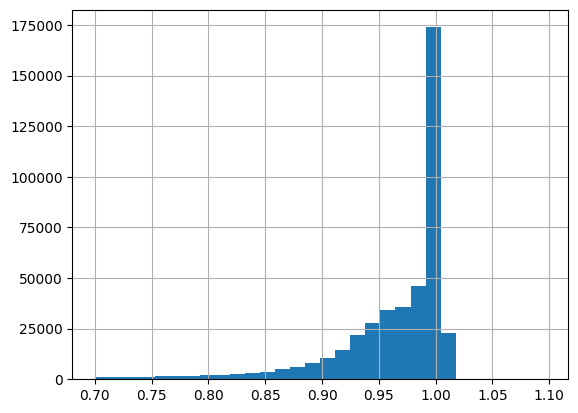

In [149]:
# Look at the distribution of coverage
hrv_raw["coverage"].hist(bins=30)


In [150]:
# Keep the ones with at least 80% coverage
hrv_raw = hrv_raw[hrv_raw["coverage"] >= 0.8]
hrv_raw


,id,study_interval,is_weekend,day_in_study,rmssd,coverage
1,2,2022,True,7,41.079,1.005
2,2,2022,True,7,42.649,0.970
3,2,2022,True,7,41.508,0.936
4,2,2022,True,7,40.232,1.006
5,2,2022,True,8,39.195,0.996
...,...,...,...,...,...,...
436257,50,2024,False,951,52.992,0.829
436258,50,2024,False,951,55.063,1.001
436259,50,2024,False,951,48.552,1.005
436260,50,2024,False,951,58.877,0.884


In [151]:
hrv_raw["rmssd"].describe()


count    418097.000000
mean         54.811037
std          34.342522
min           0.000000
25%          30.878000
50%          46.297000
75%          69.075000
max         686.934000
Name: rmssd, dtype: float64

In [152]:
hrv_daily = hrv_raw.groupby(DAILY_MERGE_KEYS, as_index=False).agg(
    daily_hrv=('rmssd', 'median'),)

hrv_daily


,id,day_in_study,is_weekend,study_interval,daily_hrv
0,2,7,True,2022,41.2935
1,2,8,True,2022,44.6445
2,2,9,False,2022,46.3810
3,2,10,False,2022,44.0465
4,2,11,False,2022,40.6970
...,...,...,...,...,...
4833,50,947,False,2024,48.2100
4834,50,948,False,2024,44.0245
4835,50,949,False,2024,42.2470
4836,50,950,False,2024,51.2680


#### Sleep


In [153]:
sleep_score_raw = pd.read_csv(os.path.join(data_dir, 'sleep_score.csv'))


In [154]:
# Look at the proportion of exact duplicate rows in sleep_score_raw
n_dup_rows = sleep_score_raw.duplicated().sum()
n_total_rows = len(sleep_score_raw)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")


Exact duplicate rows: 61/5308
Proportion: 1.15%


In [155]:
# Remove exact duplicate rows, keeping the first occurrence
sleep_score_raw = sleep_score_raw.drop_duplicates()

sleep_score_raw


,id,study_interval,is_weekend,day_in_study,timestamp,overall_score,composition_score,revitalization_score,duration_score,deep_sleep_in_minutes,resting_heart_rate,restlessness
0,1,2022,False,4,07:42:00,80,21.0,22,37.0,93.0,84,0.056404
1,1,2022,True,7,10:04:30,81,18.0,21,42.0,86.0,82,0.035122
2,1,2022,False,11,08:03:00,83,21.0,23,39.0,53.0,76,0.047014
3,1,2022,False,12,08:06:00,80,19.0,22,39.0,49.0,77,0.051282
4,1,2022,False,20,09:35:00,82,18.0,19,45.0,113.0,76,0.075188
...,...,...,...,...,...,...,...,...,...,...,...,...
5303,50,2024,False,947,07:43:30,66,NaN,66,NaN,68.0,63,0.133333
5304,50,2024,False,948,07:33:30,65,NaN,65,NaN,72.0,63,0.103408
5305,50,2024,False,949,08:36:00,76,NaN,76,NaN,61.0,61,0.103486
5306,50,2024,False,950,08:11:00,81,NaN,81,NaN,71.0,61,0.094782


In [156]:
sleep_score_raw = sleep_score_raw[["id", "study_interval", "is_weekend", "day_in_study", "timestamp", "overall_score"]]
sleep_score_raw


,id,study_interval,is_weekend,day_in_study,timestamp,overall_score
0,1,2022,False,4,07:42:00,80
1,1,2022,True,7,10:04:30,81
2,1,2022,False,11,08:03:00,83
3,1,2022,False,12,08:06:00,80
4,1,2022,False,20,09:35:00,82
...,...,...,...,...,...,...
5303,50,2024,False,947,07:43:30,66
5304,50,2024,False,948,07:33:30,65
5305,50,2024,False,949,08:36:00,76
5306,50,2024,False,950,08:11:00,81


Unparseable timestamps: 0/5247
Earliest: 00:09:30
Latest:   23:58:00


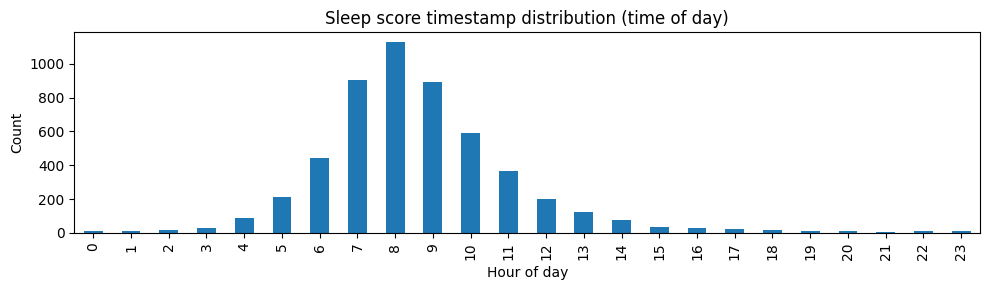

In [157]:
# Look at the distribution of timestamp (time-of-day)
ts = pd.to_timedelta(sleep_score_raw['timestamp'], errors='coerce')
print(f'Unparseable timestamps: {ts.isna().sum()}/{len(sleep_score_raw)}')

print('Earliest:', sleep_score_raw['timestamp'].min())
print('Latest:  ', sleep_score_raw['timestamp'].max())
ax = ts.dt.components['hours'].value_counts().sort_index().plot(kind='bar', figsize=(10, 3))
ax.set(xlabel='Hour of day', ylabel='Count', title='Sleep score timestamp distribution (time of day)')
plt.tight_layout()
plt.show()


ok, so likely it records the sleep of the night before, and `timestamp` here probably means something like "wake time". Thus, can use the value for that day.


In [159]:
# See if DAILY_MERGE_KEYS is unique in sleep_score_raw
sleep_score_raw[DAILY_MERGE_KEYS].drop_duplicates().shape[0] == sleep_score_raw.shape[0]


False

In [160]:
# Which duplicates?
dup_mask = sleep_score_raw.duplicated(subset=DAILY_MERGE_KEYS, keep=False)
sleep_score_raw[dup_mask].sort_values(DAILY_MERGE_KEYS)


,id,study_interval,is_weekend,day_in_study,timestamp,overall_score
80,2,2022,False,51,17:41:00,49
81,2,2022,False,51,08:38:30,82
121,3,2022,False,2,18:46:30,55
122,3,2022,False,2,07:30:30,64
124,3,2022,False,4,22:15:00,58
...,...,...,...,...,...,...
5170,50,2022,False,60,08:45:30,78
5190,50,2022,False,80,08:44:00,70
5191,50,2022,False,80,05:36:30,73
5220,50,2024,True,868,13:59:00,67


In [161]:
sleep_score_raw["overall_score"].describe()


count    5247.000000
mean       76.710501
std         8.693726
min        30.000000
25%        72.000000
50%        78.000000
75%        83.000000
max        94.000000
Name: overall_score, dtype: float64

In [162]:
# If there are duplicates, take the ones before 12:00 PM (noon) and drop the rest
ts = pd.to_timedelta(sleep_score_raw['timestamp'], errors='coerce')
before_noon = ts.dt.components['hours'] < 12
is_dup_key = sleep_score_raw.duplicated(subset=DAILY_MERGE_KEYS, keep=False)

n_before = len(sleep_score_raw)
drop_mask = is_dup_key & ~before_noon
sleep_score_raw = sleep_score_raw.loc[~drop_mask].reset_index(drop=True)

print(f'Dropped {drop_mask.sum()} duplicate-key rows at/after noon ({n_before} -> {len(sleep_score_raw)} rows)')


Dropped 129 duplicate-key rows at/after noon (5247 -> 5118 rows)


In [163]:
# For the rest of the duplicates (multiple ones before noon), take the latest one
n_before = len(sleep_score_raw)
sleep_score_raw = (
    sleep_score_raw.assign(_ts=pd.to_timedelta(sleep_score_raw['timestamp'], errors='coerce'))
    .sort_values(DAILY_MERGE_KEYS + ['_ts'])
    .drop_duplicates(subset=DAILY_MERGE_KEYS, keep='last')
    .drop(columns='_ts')
    .reset_index(drop=True)
)

print(f'After latest-before-noon dedup: {n_before} -> {len(sleep_score_raw)} rows')
print('DAILY_MERGE_KEYS unique:', sleep_score_raw[DAILY_MERGE_KEYS].drop_duplicates().shape[0] == len(sleep_score_raw))


After latest-before-noon dedup: 5118 -> 5072 rows
DAILY_MERGE_KEYS unique: True


In [164]:
# drop feature "timestamp" since we only care about the overall score
sleep_score_raw = sleep_score_raw.drop(columns=['timestamp'])
sleep_score_raw

,id,study_interval,is_weekend,day_in_study,overall_score
0,1,2022,False,4,80
1,1,2022,True,7,81
2,1,2022,False,11,83
3,1,2022,False,12,80
4,1,2022,False,20,82
...,...,...,...,...,...
5067,50,2024,False,947,66
5068,50,2024,False,948,65
5069,50,2024,False,949,76
5070,50,2024,False,950,81


In [165]:
# rename "overall_score" to "sleep_score" for clarity
sleep_score_raw.rename(columns={'overall_score': 'sleep_score'}, inplace=True)


In [166]:
sleep_score_daily = sleep_score_raw
sleep_score_daily

,id,study_interval,is_weekend,day_in_study,sleep_score
0,1,2022,False,4,80
1,1,2022,True,7,81
2,1,2022,False,11,83
3,1,2022,False,12,80
4,1,2022,False,20,82
...,...,...,...,...,...
5067,50,2024,False,947,66
5068,50,2024,False,948,65
5069,50,2024,False,949,76
5070,50,2024,False,950,81


### Merge all dataframes into one dataframe

In [167]:
# Check for duplicates in all dataframes
for name, df in {
    "active_minutes": active_minutes,
    "daily_calories": daily_calories,
    "demographic_vo2_daily": demographic_vo2_daily,
    "time_in_heart_rate_zones": time_in_heart_rate_zones,
    "hormones_and_selfreport": hormones_and_selfreport,
    "daily_glucose": daily_glucose,
    "hrv_daily": hrv_daily,
    "sleep_score_daily": sleep_score_daily,
}.items():

    dup = df.duplicated(
        subset=DAILY_MERGE_KEYS
    ).sum()

    print(f"{name}: {dup}")


active_minutes: 0
daily_calories: 0
demographic_vo2_daily: 0
time_in_heart_rate_zones: 0
hormones_and_selfreport: 0
daily_glucose: 0
hrv_daily: 0
sleep_score_daily: 0


In [168]:
# daily-level data: merge on DAILY_MERGE_KEYS
merged_df = (
    active_minutes
    .merge(
        daily_calories,
        on=DAILY_MERGE_KEYS,
        how="outer"
    )
    .merge(
        demographic_vo2_daily,
        on=DAILY_MERGE_KEYS,
        how="outer"
    )
    .merge(
        time_in_heart_rate_zones,
        on=DAILY_MERGE_KEYS,
        how="outer"
    )
    .merge(
        hormones_and_selfreport,
        on=DAILY_MERGE_KEYS,
        how="outer"
    )
    .merge(
        daily_glucose,
        on=DAILY_MERGE_KEYS,
        how="outer"
    )
    .merge(
        hrv_daily,
        on=DAILY_MERGE_KEYS,
        how="outer"
    )
    .merge(
        sleep_score_daily,
        on=DAILY_MERGE_KEYS,
        how="outer"
    )
)

# participant-level data: merge on id only
merged_df = merged_df.merge(
    subject_info,
    on="id",
    how="left"
)

print(merged_df.shape)
merged_df.head()


(5659, 27)


,id,study_interval,is_weekend,day_in_study,sedentary_activity,lightly_activity,moderately_activity,very_activity,calories_sum,filtered_demographic_vo2_max,...,pdg,exerciselevel_num,fatigue_num,daily_glucose,daily_hrv,sleep_score,age_of_first_menarche,age,menstrual_health_literacy_num,sexually_active_num
0,1,2022,True,1,753.0,64.0,0.0,0.0,1542.0,33.79370,...,NaN,2.0,4.0,5.40,NaN,NaN,14,25,NaN,1.0
1,1,2022,False,2,855.0,74.0,0.0,0.0,1591.0,32.55987,...,NaN,2.0,4.0,5.30,NaN,NaN,14,25,NaN,1.0
2,1,2022,False,3,751.0,134.0,18.0,7.0,1755.0,31.50628,...,NaN,1.0,5.0,5.70,NaN,NaN,14,25,NaN,1.0
3,1,2022,False,4,905.0,86.0,0.0,0.0,1552.0,31.06774,...,NaN,2.0,4.0,5.05,NaN,80.0,14,25,NaN,1.0
4,1,2022,False,5,1430.0,10.0,0.0,0.0,1456.0,30.88130,...,NaN,1.0,4.0,5.20,NaN,NaN,14,25,NaN,1.0


In [169]:
merged_df.columns


Index(['id', 'study_interval', 'is_weekend', 'day_in_study',
       'sedentary_activity', 'lightly_activity', 'moderately_activity',
       'very_activity', 'calories_sum', 'filtered_demographic_vo2_max',
       'peak_zone', 'cardio_zone', 'fat_burn_zone', 'below_fat_burn_zone',
       'phase', 'lh', 'estrogen', 'pdg', 'exerciselevel_num', 'fatigue_num',
       'daily_glucose', 'daily_hrv', 'sleep_score', 'age_of_first_menarche',
       'age', 'menstrual_health_literacy_num', 'sexually_active_num'],
      dtype='object')

In [170]:
merged_df.to_csv("../../mcphases/merged/physical_activity_merged.csv", index=False)
